# Чекпоинт 7

Стек (`mlflow/docker-compose.yml`): MLflow (`localhost:5000`, backend SQLite) +
MinIO (`localhost:9001`, бакет `mlflow`). Артефакты проксируются через сервер.

## 1. Подключение к MLflow

In [1]:
import os
import time
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, brier_score_loss, confusion_matrix, roc_curve,
)

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

from prematch_data import load_prematch_data, RANDOM_STATE

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_STATE)

In [2]:
MLFLOW_TRACKING_URI = os.environ.get('MLFLOW_TRACKING_URI', 'http://localhost:5000')
EXPERIMENT_NAME = 'tennis-prematch'
REGISTERED_MODEL = 'tennis-prematch-gb'
PRD_ALIAS = 'PRD'

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
client = MlflowClient()
mlflow.get_tracking_uri()

'http://localhost:5000'

## 2. Данные


In [3]:
data = load_prematch_data(seed=RANDOM_STATE)
X_train, X_test = data.X_train, data.X_test
y_train, y_test = data.y_train, data.y_test
feature_names = data.feature_names
data.provenance

[prematch_data] building dataset (first run is slow: odds matching)...


[prematch_data] built in 54.6s, selected 30 features, odds coverage 34.15%


{'seed': 42,
 'n_rows': 95367,
 'n_train': 76293,
 'n_test': 19074,
 'norm_dataframe_md5': 'cbca609186f88182d7633e3ce936b5be',
 'n_base_features': 26,
 'n_feat_all': 78,
 'n_selected': 30,
 'feature_set': 'FEAT_SELECTED',
 'odds_coverage_pct': 34.15,
 'data_source': 'norm_dataframe.csv (ATP 1968-2024) + DATASETS/odds + atp_matches',
 'build_seconds': 54.6}

In [4]:
{
    'X_train': X_train.shape,
    'X_test': X_test.shape,
    'n_features': len(feature_names),
    'balance_train': np.bincount(y_train).tolist(),
    'balance_test': np.bincount(y_test).tolist(),
}

{'X_train': (76293, 30),
 'X_test': (19074, 30),
 'n_features': 30,
 'balance_train': [38203, 38090],
 'balance_test': [9551, 9523]}

## 3. Выбор финальной модели


In [5]:
BEST_PARAMS = dict(n_estimators=100, max_depth=5, learning_rate=0.05,
                   random_state=RANDOM_STATE)
BEST_PARAMS

{'n_estimators': 100,
 'max_depth': 5,
 'learning_rate': 0.05,
 'random_state': 42}

## 4. Вспомогательные функции

In [6]:
def full_metrics(y_true, proba):
    pred = (proba > 0.5).astype(int)
    return {
        'roc_auc': float(roc_auc_score(y_true, proba)),
        'accuracy': float(accuracy_score(y_true, pred)),
        'precision': float(precision_score(y_true, pred, zero_division=0)),
        'recall': float(recall_score(y_true, pred, zero_division=0)),
        'f1': float(f1_score(y_true, pred, zero_division=0)),
        'log_loss': float(log_loss(y_true, np.clip(proba, 1e-7, 1 - 1e-7))),
        'brier': float(brier_score_loss(y_true, proba)),
    }

def log_df_artifact(df, fname, artifact_path):
    p = os.path.join(tempfile.gettempdir(), fname)
    df.to_csv(p, index=False)
    mlflow.log_artifact(p, artifact_path=artifact_path)

In [7]:
def fig_confusion(y_true, proba, title):
    cm = confusion_matrix(y_true, (proba > 0.5).astype(int))
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Loss (0)', 'Win (1)'],
                yticklabels=['Loss (0)', 'Win (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)
    fig.tight_layout()
    return fig

def fig_roc(y_true, proba, title):
    fpr, tpr, _ = roc_curve(y_true, proba)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.plot(fpr, tpr, lw=1.6, label=f'AUC={roc_auc_score(y_true, proba):.3f}')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title(title)
    ax.legend(loc='lower right'); ax.grid(alpha=0.3); fig.tight_layout()
    return fig

def fig_importance(model, names, title, top=20):
    imp = pd.Series(model.feature_importances_, index=names).sort_values()[-top:]
    fig, ax = plt.subplots(figsize=(6.5, 6))
    imp.plot.barh(ax=ax, color='steelblue')
    ax.set_title(title); ax.set_xlabel('importance'); fig.tight_layout()
    return fig

def fig_calibration(y_true, proba, title, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(proba, bins) - 1, 0, n_bins - 1)
    xs, ys, cs = [], [], []
    for b in range(n_bins):
        sel = idx == b
        if sel.sum():
            xs.append(proba[sel].mean()); ys.append(y_true[sel].mean()); cs.append(int(sel.sum()))
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.plot(xs, ys, 'o-', lw=1.6)
    for x, y, cnt in zip(xs, ys, cs):
        ax.annotate(str(cnt), (x, y), fontsize=7, alpha=0.6,
                    xytext=(3, 3), textcoords='offset points')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('predicted'); ax.set_ylabel('empirical'); ax.set_title(title)
    ax.grid(alpha=0.3); fig.tight_layout()
    return fig

## 5. Переобучение и логирование

Открываем MLflow-ран и логируем гиперпараметры, метрики train/CV/test, артефакты
(модель, графики, примеры предсказаний) в S3/MinIO.

In [8]:
run = mlflow.start_run(run_name='GB_FEAT_SELECTED_PRD')
run_id = run.info.run_id

mlflow.log_params(BEST_PARAMS)
mlflow.log_params({
    'model_type': 'GradientBoostingClassifier',
    'feature_set': 'FEAT_SELECTED',
    'n_features': len(feature_names),
    'test_size': 0.2, 'cv_folds': 3, 'seed': RANDOM_STATE,
    'grid_searched': 'n_est[100,200]xdepth[3,4,5]xlr[0.05,0.1]',
})
for k, v in data.provenance.items():
    mlflow.log_param(f'data_{k}', v)
mlflow.set_tags({'task': 'pre-match win prediction', 'checkpoint': '7',
                 'stage_intent': 'PRD'})
run_id

'22c8bd32221e401ab057660b3c723592'

In [9]:
t0 = time.time()
gb = GradientBoostingClassifier(**BEST_PARAMS)
gb.fit(X_train, y_train)
fit_s = time.time() - t0
mlflow.log_metric('fit_seconds', fit_s)
{'fit_seconds': round(fit_s, 1)}

{'fit_seconds': 116.3}

In [10]:
cv_auc = cross_val_score(GradientBoostingClassifier(**BEST_PARAMS),
                         X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
mlflow.log_metric('val_roc_auc_cv', float(cv_auc.mean()))
mlflow.log_metric('val_roc_auc_cv_std', float(cv_auc.std()))
{'cv_folds': cv_auc.round(4).tolist(), 'cv_mean': round(float(cv_auc.mean()), 4)}

{'cv_folds': [0.7356, 0.7327, 0.7412], 'cv_mean': 0.7365}

In [11]:
proba_train = gb.predict_proba(X_train)[:, 1]
proba_test = gb.predict_proba(X_test)[:, 1]
m_train = full_metrics(y_train, proba_train)
m_test = full_metrics(y_test, proba_test)
for k, v in m_train.items():
    mlflow.log_metric(f'train_{k}', v)
for k, v in m_test.items():
    mlflow.log_metric(f'test_{k}', v)
pd.DataFrame({'train': m_train, 'test': m_test}).round(4)

,train,test
roc_auc,0.7527,0.7386
accuracy,0.6807,0.6714
precision,0.6795,0.6713
recall,0.6823,0.6700
f1,0.6809,0.6706
log_loss,0.5865,0.5989
brier,0.2016,0.2067


### Графики (логируются в S3 и показываются ниже)

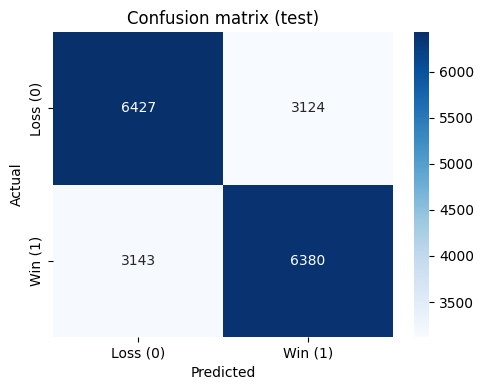

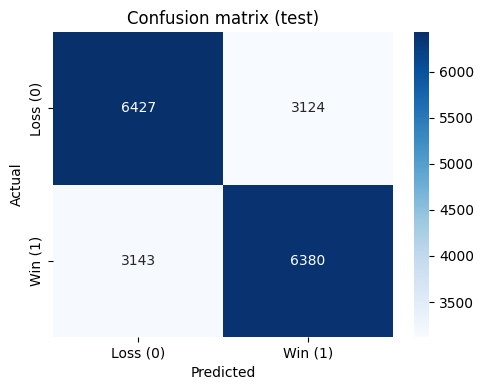

In [12]:
fig = fig_confusion(y_test, proba_test, 'Confusion matrix (test)')
mlflow.log_figure(fig, 'plots/confusion_matrix.png')
fig

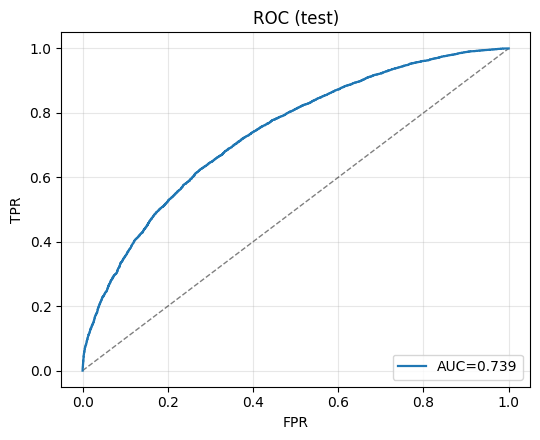

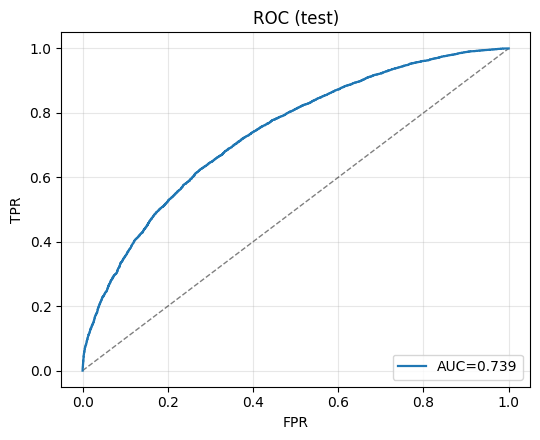

In [13]:
fig = fig_roc(y_test, proba_test, 'ROC (test)')
mlflow.log_figure(fig, 'plots/roc_curve.png')
fig

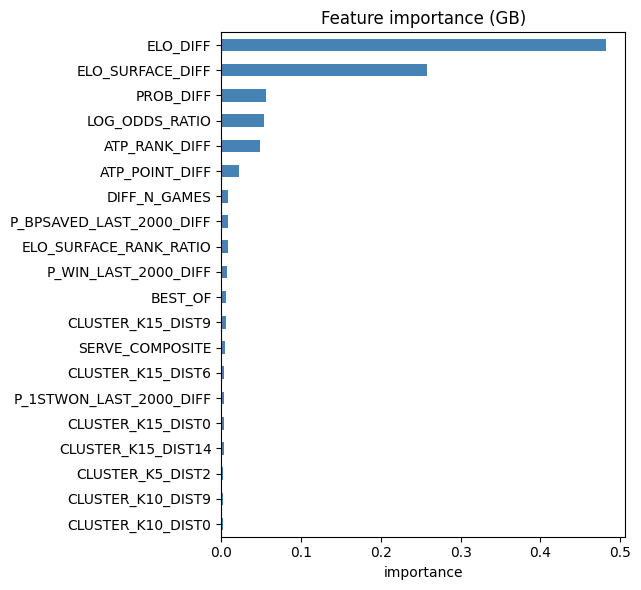

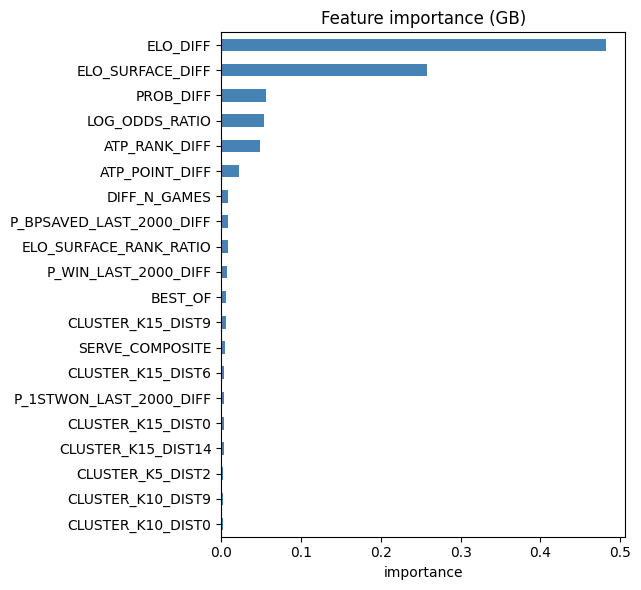

In [14]:
fig = fig_importance(gb, feature_names, 'Feature importance (GB)')
mlflow.log_figure(fig, 'plots/feature_importance.png')
fig

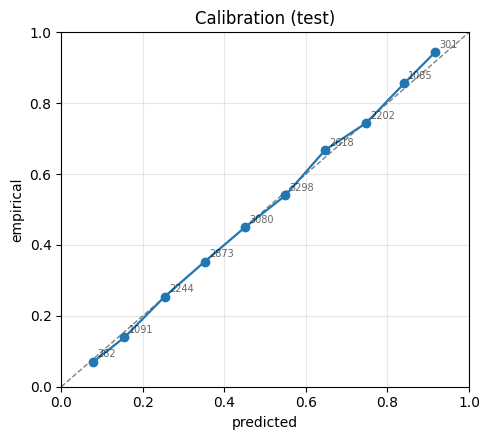

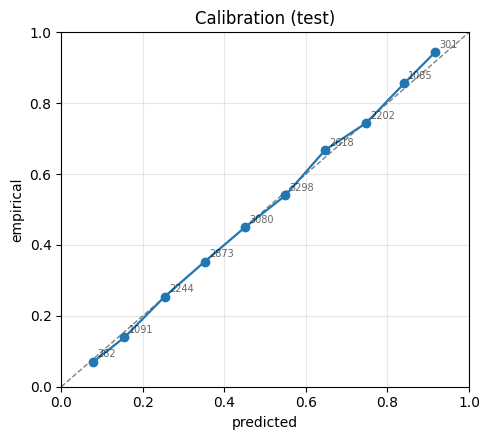

In [15]:
fig = fig_calibration(y_test, proba_test, 'Calibration (test)')
mlflow.log_figure(fig, 'plots/calibration.png')
fig

### Список признаков и примеры предсказаний

In [16]:
mlflow.log_dict({'feature_set': 'FEAT_SELECTED', 'features': feature_names},
                'feature_names.json')
sample = data.meta_test.copy()
sample['proba_player1_win'] = proba_test
sample['pred'] = (proba_test > 0.5).astype(int)
log_df_artifact(sample.head(50), 'predictions_examples.csv', 'examples')
sample.head()

,PLAYER_1_NAME,PLAYER_2_NAME,tourney_date,ELO_DIFF,ELO_SURFACE_DIFF,ATP_RANK_DIFF,ODDS_P1,ODDS_P2,PROB_DIFF,RESULT,proba_player1_win,pred
33884,Michael Chang,Jan Michael Gambill,2002-06-10,-157.955327,-32.410128,-44.0,NaN,NaN,0.000000,0,0.390203,0
32282,Pete Sampras,Alberto Martin,2001-08-06,197.374206,372.969132,26.0,NaN,NaN,0.000000,0,0.750625,1
22859,Albert Portas,Emilio Benfele Alvarez,1998-04-13,76.065426,36.464515,64.0,NaN,NaN,0.000000,0,0.590750,1
65645,Grigor Dimitrov,Filippo Volandri,2013-07-08,312.064067,178.862887,72.0,1.35,3.09,0.417116,1,0.738456,1
88981,Alex De Minaur,Filip Krajinovic,2022-08-29,36.064196,136.786715,24.0,NaN,NaN,0.000000,1,0.655431,1


### Логирование модели (sklearn-флейвор)

In [17]:
signature = infer_signature(X_test, proba_test)
mlflow.sklearn.log_model(gb, artifact_path='model', signature=signature,
                         input_example=X_test[:5])
f'runs:/{run_id}/model'

'runs:/22c8bd32221e401ab057660b3c723592/model'

## 6. Фиксация финальной версии алиас PRD

Регистрируем модель и вешаем алиас **PRD**; сервисный ноутбук грузит её по
`models:/tennis-prematch-gb@PRD`.

In [18]:
mv = mlflow.register_model(f'runs:/{run_id}/model', REGISTERED_MODEL)
client.set_registered_model_alias(REGISTERED_MODEL, PRD_ALIAS, mv.version)
client.set_model_version_tag(REGISTERED_MODEL, mv.version, 'stage', 'PRD')
client.update_model_version(REGISTERED_MODEL, mv.version,
    description='Финальная PRD-модель: pre-match GradientBoosting на FEAT_SELECTED (ЧП5).')
{'model': REGISTERED_MODEL, 'version': mv.version, 'alias': PRD_ALIAS}

Registered model 'tennis-prematch-gb' already exists. Creating a new version of this model...
2026/05/31 20:46:30 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: tennis-prematch-gb, version 2


Created version '2' of model 'tennis-prematch-gb'.


{'model': 'tennis-prematch-gb', 'version': '2', 'alias': 'PRD'}

## 7. Анализ ошибок

Разбираем ошибочные предсказания на test, выделяем категории и смотрим конкретные
примеры. `meta_test` содержит имена игроков, дату, Elo/ранг-диффы и odds.

In [19]:
err = data.meta_test.copy()
err['proba'] = proba_test
err['pred'] = (proba_test > 0.5).astype(int)
err['correct'] = (err['pred'] == err['RESULT']).astype(int)
err['confidence'] = (err['proba'] - 0.5).abs()
wrong = err[err['correct'] == 0].copy()
{'errors': int(len(wrong)), 'total': int(len(err)),
 'error_rate': round(len(wrong) / len(err), 3)}

{'errors': 6267, 'total': 19074, 'error_rate': 0.329}

In [20]:
def categorize(r):
    base = 'no_market_odds' if pd.isna(r['ODDS_P1']) else 'has_odds'
    if r['confidence'] < 0.05:
        return 'toss_up (|p-0.5|<0.05)'
    if r['confidence'] > 0.25:
        return f'high_conf_upset ({base})'
    return f'mid_conf ({base})'

wrong['category'] = wrong.apply(categorize, axis=1)
wrong['category'].value_counts()

category
mid_conf (no_market_odds)           2573
toss_up (|p-0.5|<0.05)              1579
mid_conf (has_odds)                 1332
high_conf_upset (no_market_odds)     445
high_conf_upset (has_odds)           338
Name: count, dtype: int64

In [21]:
cols = ['PLAYER_1_NAME', 'PLAYER_2_NAME', 'tourney_date', 'RESULT', 'pred',
        'proba', 'ELO_DIFF', 'ATP_RANK_DIFF', 'ODDS_P1', 'ODDS_P2', 'category']
top_errors = wrong.sort_values('confidence', ascending=False).head(15)[cols].reset_index(drop=True)
top_errors

,PLAYER_1_NAME,PLAYER_2_NAME,tourney_date,RESULT,pred,proba,ELO_DIFF,ATP_RANK_DIFF,ODDS_P1,ODDS_P2,category
0,Hugo Gaston,Stan Wawrinka,2020-09-28,1,0,0.056829,-409.126491,-222.0,11.69,1.04,high_conf_upset (has_odds)
1,Vasek Pospisil,Andy Murray,2017-03-06,1,0,0.068635,-603.525161,-128.0,11.99,1.04,high_conf_upset (has_odds)
2,Jo-Wilfried Tsonga,Renzo Olivo,2017-05-29,0,1,0.929938,566.472137,80.0,1.02,16.04,high_conf_upset (has_odds)
3,Lleyton Hewitt,Ivo Karlovic,2003-06-23,0,1,0.924412,515.742223,201.0,NaN,NaN,high_conf_upset (no_market_odds)
4,Damir Dzumhur,Rafael Nadal,2016-03-21,1,0,0.076294,-456.949969,-89.0,10.72,1.04,high_conf_upset (has_odds)
5,Rafael Nadal,Martin Klizan,2014-09-29,0,1,0.922524,460.103727,54.0,1.07,8.14,high_conf_upset (has_odds)
6,Robin Soderling,Marcel Granollers,2010-01-18,0,1,0.921435,470.770422,105.0,NaN,NaN,high_conf_upset (no_market_odds)
7,Benoit Paire,Kei Nishikori,2015-08-31,1,0,0.079278,-349.471159,-37.0,8.23,1.07,high_conf_upset (has_odds)
8,Marin Cilic,Guido Pella,2018-07-02,0,1,0.920515,323.164361,77.0,1.03,14.07,high_conf_upset (has_odds)
9,Tomas Berdych,Stephane Robert,2011-05-22,0,1,0.919991,390.434477,134.0,1.05,9.85,high_conf_upset (has_odds)


In [22]:
log_df_artifact(top_errors, 'top_errors.csv', 'error_analysis')
cat_counts = wrong['category'].value_counts().rename_axis('category').reset_index(name='count')
log_df_artifact(cat_counts, 'error_categories.csv', 'error_analysis')
mlflow.log_metric('test_error_rate', float(len(wrong) / len(err)))
cat_counts

,category,count
0,mid_conf (no_market_odds),2573
1,toss_up (|p-0.5|<0.05),1579
2,mid_conf (has_odds),1332
3,high_conf_upset (no_market_odds),445
4,high_conf_upset (has_odds),338


### Интерпретация ошибок

* **`high_conf_upset`** — модель уверенно ставила на фаворита, победил андердог.
  Апсеты — внутренне случайная компонента (травма, исключительный день). На момент
  pre-match-прогноза информации нет → **неустранимо**.
* **`toss_up`** — `p≈0.5`, равные соперники; ошибка ожидаема и **неустранима**.
* **`no_market_odds`** — нет коэффициентов (покрытие ≈34%), модель лишена сильнейшего
  признака. **Частично устранимо**: расширение источника odds подняло бы точность.
* **`mid_conf`** — пограничные предсказания; частично устранимы добавлением контекста.

Вывод: большинство ошибок — апсеты и равные матчи (неустранимо); практический рычаг —
покрытие odds-признаков.

## 8. Сравнение с baseline

Baseline-1: логистическая регрессия (C=0.01) на тех же признаках. Baseline-2: рыночная
эвристика — фаворит = меньший коэффициент (на подмножестве с odds).

In [23]:
lr = LogisticRegression(C=0.01, penalty='l2', solver='liblinear',
                        max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
proba_lr = lr.predict_proba(X_test)[:, 1]
m_lr = full_metrics(y_test, proba_lr)

mask_odds = data.meta_test['ODDS_P1'].notna().values
p1 = data.meta_test['ODDS_P1'].values[mask_odds]
p2 = data.meta_test['ODDS_P2'].values[mask_odds]
heur_pred = (p1 < p2).astype(int)
heur_acc = accuracy_score(y_test[mask_odds], heur_pred)
heur_proba = (1 / p1) / (1 / p1 + 1 / p2)
heur_auc = roc_auc_score(y_test[mask_odds], heur_proba)
gb_auc_oddsonly = roc_auc_score(y_test[mask_odds], proba_test[mask_odds])

compare = pd.DataFrame([
    {'model': 'GradientBoosting (PRD)', 'ROC_AUC': m_test['roc_auc'], 'Accuracy': m_test['accuracy'], 'scope': 'all test'},
    {'model': 'LogReg baseline', 'ROC_AUC': m_lr['roc_auc'], 'Accuracy': m_lr['accuracy'], 'scope': 'all test'},
    {'model': 'Market favourite heuristic', 'ROC_AUC': heur_auc, 'Accuracy': heur_acc, 'scope': 'odds subset'},
    {'model': 'GradientBoosting (PRD)', 'ROC_AUC': gb_auc_oddsonly, 'Accuracy': np.nan, 'scope': 'odds subset'},
]).round(4)
compare

,model,ROC_AUC,Accuracy,scope
0,GradientBoosting (PRD),0.7386,0.6714,all test
1,LogReg baseline,0.7341,0.6693,all test
2,Market favourite heuristic,0.7634,0.6922,odds subset
3,GradientBoosting (PRD),0.7587,NaN,odds subset


In [24]:
for k, v in m_lr.items():
    mlflow.log_metric(f'baseline_logreg_{k}', v)
mlflow.log_metric('baseline_market_acc', float(heur_acc))
mlflow.log_metric('baseline_market_auc', float(heur_auc))
log_df_artifact(compare, 'baseline_comparison.csv', 'baseline')
{'logreg_auc': round(m_lr['roc_auc'], 4), 'market_auc': round(float(heur_auc), 4)}

{'logreg_auc': 0.7341, 'market_auc': 0.7634}

**Интерпретация.** GradientBoosting обгоняет линейный baseline по ROC-AUC (нелинейные
взаимодействия и кластеры дают прирост). На подмножестве с odds рыночная эвристика —
сильный baseline; модель использует те же odds как признак и добавляет ценность там,
где odds отсутствуют (≈66% матчей).

## 9. Проверка устойчивости

Вносим гауссов шум разной амплитуды в стандартизованные признаки и смотрим средний
сдвиг вероятности, долю перевернувшихся предсказаний и деградацию ROC-AUC.

In [25]:
rng = np.random.default_rng(RANDOM_STATE)
base_pred = (proba_test > 0.5).astype(int)
rows = []
for sigma in [0.01, 0.05, 0.1, 0.2, 0.5]:
    dp, flips, aucs = [], [], []
    for _ in range(5):
        Xp = X_test + rng.normal(0, sigma, X_test.shape)
        pr = gb.predict_proba(Xp)[:, 1]
        dp.append(np.abs(pr - proba_test).mean())
        flips.append(((pr > 0.5).astype(int) != base_pred).mean())
        aucs.append(roc_auc_score(y_test, pr))
    rows.append({'sigma': sigma, 'mean_abs_dproba': np.mean(dp),
                 'flip_rate': np.mean(flips), 'roc_auc': np.mean(aucs)})
robust = pd.DataFrame(rows).round(4)
robust

,sigma,mean_abs_dproba,flip_rate,roc_auc
0,0.01,0.0142,0.0244,0.7369
1,0.05,0.0305,0.0603,0.7331
2,0.10,0.0395,0.0829,0.7294
3,0.20,0.0516,0.1176,0.7222
4,0.50,0.0763,0.1843,0.7001


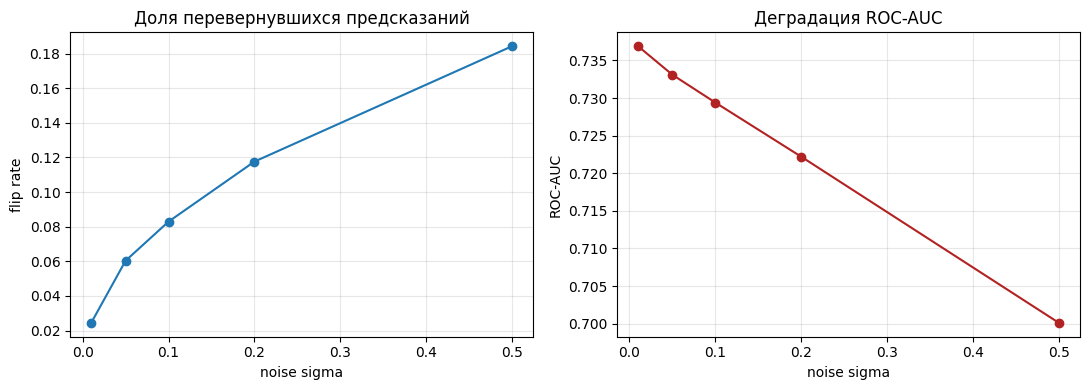

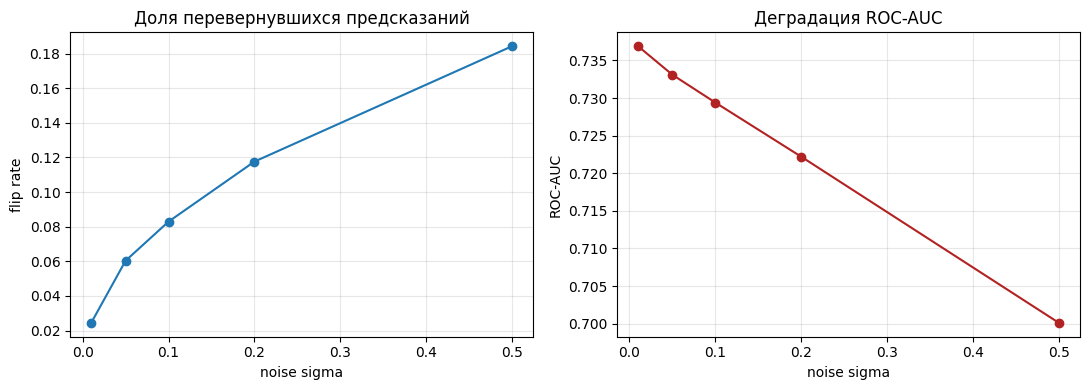

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(robust['sigma'], robust['flip_rate'], 'o-')
ax[0].set_xlabel('noise sigma'); ax[0].set_ylabel('flip rate')
ax[0].set_title('Доля перевернувшихся предсказаний'); ax[0].grid(alpha=0.3)
ax[1].plot(robust['sigma'], robust['roc_auc'], 'o-', color='firebrick')
ax[1].set_xlabel('noise sigma'); ax[1].set_ylabel('ROC-AUC')
ax[1].set_title('Деградация ROC-AUC'); ax[1].grid(alpha=0.3)
fig.tight_layout()
mlflow.log_figure(fig, 'plots/robustness.png')
fig

In [27]:
log_df_artifact(robust, 'robustness.csv', 'robustness')
mlflow.log_metric('robust_auc_sigma_0.1', float(robust.loc[robust.sigma == 0.1, 'roc_auc'].iloc[0]))
mlflow.end_run()
{'run_id': run_id, 'status': 'finished'}

2026/05/31 20:46:33 INFO mlflow.tracking._tracking_service.client: 🏃 View run GB_FEAT_SELECTED_PRD at: http://localhost:5000/#/experiments/1/runs/22c8bd32221e401ab057660b3c723592.


2026/05/31 20:46:33 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/1.


{'run_id': '22c8bd32221e401ab057660b3c723592', 'status': 'finished'}

**Наблюдения.** При малом шуме (σ≤0.05) предсказания почти не меняются, ROC-AUC
стабильна — модель устойчива. С ростом σ flip-rate растёт за счёт пограничных матчей
(`p≈0.5`), ROC-AUC деградирует плавно, без резких разрывов.

## 10. Итоги

* Финальная модель **GradientBoosting + FEAT_SELECTED** переобучена воспроизводимо
  и зафиксирована в MLflow Registry с алиасом **PRD**.
* Залогированы гиперпараметры, метрики train/CV/test и артефакты в S3/MinIO.
* Анализ ошибок: доминируют неустранимые апсеты и равные матчи.
* Модель превосходит линейный baseline и устойчива к малым возмущениям входов.
* Загрузка PRD и тестовый предикт — в `checkpoint7_serve.ipynb`.